In [5]:
import numpy as np 
import h5py
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MultipleLocator
import os
import sys
import re
from tqdm import tqdm
from scipy.optimize import curve_fit

# import some tools from the wider directory
sys.path.insert(0, os.path.abspath('..'))   # adds fastersimulation/ to the path
import utilities
path = "../results/const_pid_refined_orbital_sweep/"
out_path = os.path.join(path, "combined_dt_sweep.h5")
collate=False

In [2]:
# path relative to where you run this script
path = "../results/const_pid_refined_orbital_sweep/"
it_num = 0
if collate==True:
    def _parse_folder(folder_name):
        """
        Extract a, e, i, raan from folder names like:
        sim_a1.40e+07_e0.8_i180.0_raan0.0
        """
        m = re.search(r"sim_a([^_]+)_e([^_]+)_i([^_]+)_raan([^_]+)", folder_name)
        if m:
            try:
                return (
                    float(m.group(1)),  # a
                    float(m.group(2)),  # e
                    float(m.group(3)),  # i
                    float(m.group(4)),  # raan
                )
            except ValueError:
                pass
        return -1.0, -1.0, -1.0, -1.0
    
    # Discover all simulation folders
    sweep_dirs = [
        d for d in os.listdir(path)
        if os.path.isdir(os.path.join(path, d)) and d.startswith("sim_a")
    ]
    
    # Sort hierarchically by a, then e, then i, then raan
    sweep_dirs.sort(key=lambda d: _parse_folder(d))
    
    out_path = os.path.join(path, "combined_dt_sweep.h5")
    missing = []
    
    print(f"Collating {len(sweep_dirs)} folders into {out_path}...")
    
    with h5py.File(out_path, "w") as out_f:
        for folder in tqdm(sweep_dirs):
            a, e, i, raan = _parse_folder(folder)
            if it_num > 100:
                break
            it_num += 1
            if a < 0:
                print(f"  [SKIP] {folder} — could not parse parameters")
                continue
    
            h5_path = os.path.join(path, folder, "mirror_states.h5")
            if not os.path.isfile(h5_path):
                print(f"  [SKIP] a={a}, e={e}, i={i}, raan={raan} — mirror_states.h5 not found")
                missing.append(folder)
                continue
    
            # Create a unique group name for this configuration
            group_name = f"a_{a:.6g}_e_{e:.6g}_i_{i:.6g}_raan_{raan:.6g}"
    
            with h5py.File(h5_path, "r") as src_f:
                dst_grp = out_f.create_group(group_name)
    
                # Copy everything from the source file ro ot into the new group
                for key in src_f.keys():
                    src_f.copy(key, dst_grp, name=key)
    
            #print(f"  [OK]   {folder}  →  {group_name}/")
    print(f"\nSaved combined file → {out_path}")
    if missing:
        print(f"WARNING: {len(missing)} folders had no mirror_states.h5 file!")

In [3]:
def _h5_tree(item, indent=0, max_seg=2, first_only=False):
    """Recursively print an HDF5 tree, optionally only the first root group."""
    prefix = "  " * indent

    def _parse_root_group(name):
        if not name.startswith("a_"):
            return (-1.0, -1.0, -1.0, -1.0)
        parts = name.split("_")
        try:
            return (
                float(parts[1]),
                float(parts[3]),
                float(parts[5]),
                float(parts[7]),
            )
        except (IndexError, ValueError):
            return (-1.0, -1.0, -1.0, -1.0)

    def _segment_index(name):
        try:
            return int(name.split("_")[1])
        except (IndexError, ValueError):
            return -1

    if isinstance(item, h5py.File):
        print(f"{prefix}/ (attrs: {dict(item.attrs)})")

        children = sorted(item.keys(), key=_parse_root_group)

        if first_only and children:
            _h5_tree(item[children[0]], indent + 1, max_seg, first_only)
        else:
            for k in children:
                _h5_tree(item[k], indent + 1, max_seg, first_only)

    elif isinstance(item, h5py.Group):
        name = item.name.split("/")[-1]
        children = list(item.keys())

        seg_keys = sorted(
            [k for k in children if k.startswith("segment_")],
            key=_segment_index
        )
        other_keys = sorted(
            [k for k in children if not k.startswith("segment_")]
        )

        print(f"{prefix}┣ {name}/")

        for k in other_keys:
            _h5_tree(item[k], indent + 1, max_seg, first_only)

        for k in seg_keys[:max_seg]:
            _h5_tree(item[k], indent + 1, max_seg, first_only)

        if len(seg_keys) > max_seg:
            print(f"{'  ' * (indent + 1)}┆ ... ({len(seg_keys) - max_seg} more segment_ groups)")

    elif isinstance(item, h5py.Dataset):
        name = item.name.split("/")[-1]
        print(f"{prefix}┃  {name:30s}  {str(item.shape):20s}  {item.dtype}")


# ── Execute ──
with h5py.File(out_path, "r") as f:
    _h5_tree(f, max_seg=1, first_only=True)

/ (attrs: {})
  ┣ a_8e+06_e_0.8_i_0_raan_0/
    ┣ config/
      ┃  star_vector                     (3,)                  float64
    ┃  mirror_time                     (90000,)              float64
    ┃  phase                           (106817,)             object
    ┃  r_app_eci                       (106817, 3)           float64
    ┃  r_det_eci                       (106817, 3)           float64
    ┃  rel_pos_B                       (90000, 3)            float64
    ┃  rel_sigma_B                     (106817, 3)           float64
    ┃  sigma_app_star                  (106817, 3)           float64
    ┃  sigma_det_star                  (106817, 3)           float64
    ┃  time                            (106817,)             float64
    ┣ segment_0/
      ┃  desired_mirror_actuation        (90000, 6)            float64
      ┃  mirror_actuation                (90000, 6)            float64
      ┃  point_on_det_plane              (90000, 2)            float64
      ┃  position    

In [4]:
with h5py.File(out_path, "r") as src_f:

    def _parse_grp(x):
        if not x.startswith("a_"):
            return (-1.0, -1.0, -1.0, -1.0)
        parts = x.split("_")
        try:
            return (
                float(parts[1]),
                float(parts[3]),
                float(parts[5]),
                float(parts[7]),
            )
        except (IndexError, ValueError):
            return (-1.0, -1.0, -1.0, -1.0)

    def _get_ds(run_grp, name):
        if "config" in run_grp and name in run_grp["config"]:
            return run_grp["config"][name][:]
        if name in run_grp:
            return run_grp[name][:]
        raise KeyError(f"{name} not found in {run_grp.name}")

    group_keys = sorted(
        [k for k in src_f.keys() if k.startswith("a_")],
        key=_parse_grp
    )

    num_runs = len(group_keys)
    print(f"Total runs = {num_runs}")

    if num_runs == 0:
        raise ValueError("No simulation groups found.")

    first_group = group_keys[0]
    segs = sorted(
        int(k.split("_")[1])
        for k in src_f[first_group].keys()
        if k.startswith("segment_")
    )
    print(f"Segments per run = {len(segs)}")

    # ------------------------------------------------------------------
    # Containers
    # ------------------------------------------------------------------
    phase = []
    full_times = []
    eng_times = []

    a_vals, e_vals, i_vals, raan_vals = [], [], [], []

    r_app_eci = []
    r_det_eci = []
    rel_pos_B = []

    sigma_app_star = []
    sigma_det_star = []
    rel_sigma_B = []

    mirror_actuation = []
    desired_mirror_actuation = []
    point_on_det_plane = []

    # ------------------------------------------------------------------
    # Load
    # ------------------------------------------------------------------
    for group in tqdm(group_keys):
        run_grp = src_f[group]
        a, e, i, raan = _parse_grp(group)

        a_vals.append(a)
        e_vals.append(e)
        i_vals.append(i)
        raan_vals.append(raan)

        # Phase (string)
        phase_arr = _get_ds(run_grp, "phase")
        phase.append(np.array(phase_arr, dtype=str))

        # Time
        full_times.append(_get_ds(run_grp, "time"))
        eng_times.append(_get_ds(run_grp, "mirror_time"))

        # Positions
        r_app_eci.append(_get_ds(run_grp, "r_app_eci"))
        r_det_eci.append(_get_ds(run_grp, "r_det_eci"))
        rel_pos_B.append(_get_ds(run_grp, "rel_pos_B"))

        # Attitudes
        sigma_app_star.append(_get_ds(run_grp, "sigma_app_star"))
        sigma_det_star.append(_get_ds(run_grp, "sigma_det_star"))
        rel_sigma_B.append(_get_ds(run_grp, "rel_sigma_B"))

        # Segment data
        ma_segments = []
        dma_segments = []
        podp_segments = []

        for s in segs:
            seg_grp = run_grp[f"segment_{s}"]

            ma_segments.append(seg_grp["mirror_actuation"][:])
            dma_segments.append(seg_grp["desired_mirror_actuation"][:])
            podp_segments.append(seg_grp["point_on_det_plane"][:])

        mirror_actuation.append(ma_segments)
        desired_mirror_actuation.append(dma_segments)
        point_on_det_plane.append(podp_segments)

print("Data loaded into lists.")

Total runs = 101
Segments per run = 7


100%|██████████| 101/101 [01:18<00:00,  1.28it/s]

Data loaded into lists.


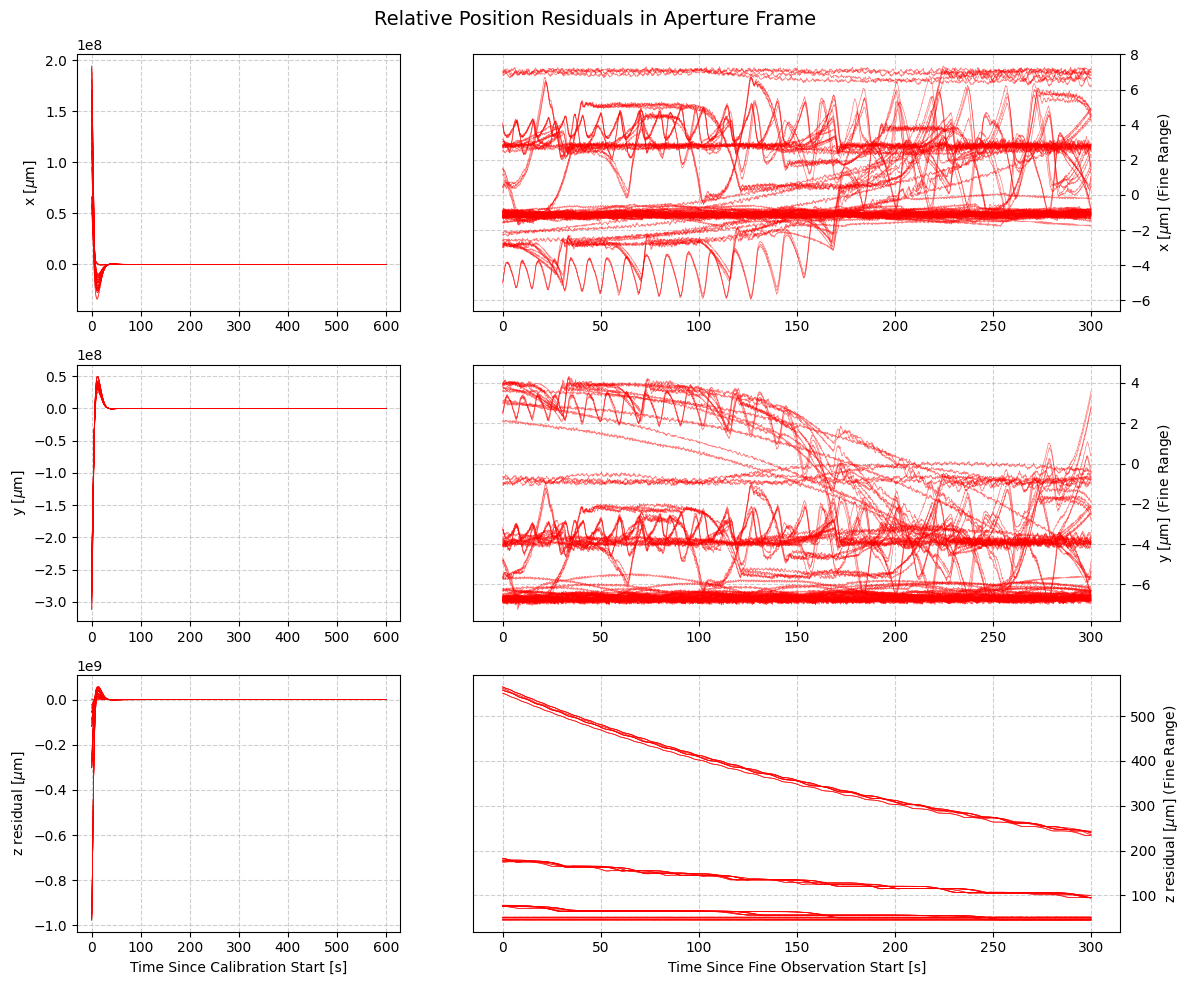

In [5]:
coord_letter = ["x", "y", "z"]

alpha_lines = 0.5
current_focal = 5000.0

rel_pos_fig = plt.figure(figsize=(12, 10))
gs = gridspec.GridSpec(3, 2, width_ratios=[1, 2], figure=rel_pos_fig)
rel_pos_fig.suptitle("Relative Position Residuals in Aperture Frame", fontsize=14)

rel_pos_ax = []

for row in range(3):
    ax_cal = rel_pos_fig.add_subplot(gs[row, 0])
    ax_fine = rel_pos_fig.add_subplot(gs[row, 1])

    ax_fine.yaxis.tick_right()
    ax_fine.yaxis.set_label_position("right")

    rel_pos_ax.append((ax_cal, ax_fine))

rel_pos_ax[2][0].set_xlabel("Time Since Calibration Start [s]")
rel_pos_ax[2][1].set_xlabel("Time Since Fine Observation Start [s]")

for coord in range(len(coord_letter)):
    label = coord_letter[coord]
    if coord == 2:
        label = "z residual"

    rel_pos_ax[coord][0].set_ylabel(f"{label} [$\\mu$m]")
    rel_pos_ax[coord][1].set_ylabel(f"{label} [$\\mu$m] (Fine Range)")
    rel_pos_ax[coord][0].grid(True, linestyle="--", alpha=0.6)
    rel_pos_ax[coord][1].grid(True, linestyle="--", alpha=0.6)

# Loop over all simulation runs and their parameters together
for i, (a, e, inc, raan) in enumerate(zip(a_vals, e_vals, i_vals, raan_vals)):
    t_eng = eng_times[i]
    rel = rel_pos_B[i]

    cal_idx = np.where(phase[i] == "Calibration")[0]
    fine_idx = np.where(phase[i] == "Fine Observation")[0]

    if len(cal_idx) > 0:
        cal_start, cal_end = full_times[i][cal_idx[0]], full_times[i][cal_idx[-1]]
        cal_mask = (t_eng >= cal_start) & (t_eng <= cal_end)
    else:
        cal_mask = np.zeros_like(t_eng, dtype=bool)

    if len(fine_idx) > 0:
        fine_start, fine_end = full_times[i][fine_idx[0]], full_times[i][fine_idx[-1]]
        fine_mask = (t_eng >= fine_start) & (t_eng <= fine_end)
    else:
        fine_mask = np.zeros_like(t_eng, dtype=bool)

    cal_t = t_eng[cal_mask]
    cal_rel = rel[cal_mask]

    fine_t = t_eng[fine_mask]
    fine_rel = rel[fine_mask]

    if len(cal_t) > 0:
        cal_t = cal_t - cal_t[0]
    if len(fine_t) > 0:
        fine_t = fine_t - fine_t[0]

    for coord in range(len(coord_letter)):
        cal_vals = cal_rel[:, coord] if len(cal_rel) > 0 else np.array([])
        fine_vals = fine_rel[:, coord] if len(fine_rel) > 0 else np.array([])

        if coord == 2:
            cal_vals = cal_vals - current_focal
            fine_vals = fine_vals - current_focal

        if len(cal_t) > 0 and len(cal_vals) > 0:
            rel_pos_ax[coord][0].plot(
                cal_t, cal_vals * 1e6,
                linewidth=0.5, color="red", alpha=alpha_lines
            )

        if len(fine_t) > 0 and len(fine_vals) > 0:
            rel_pos_ax[coord][1].plot(
                fine_t, fine_vals * 1e6,
                linewidth=0.5, color="red", alpha=alpha_lines
            )

plt.tight_layout()
plt.subplots_adjust(wspace=0.15)
plt.show()

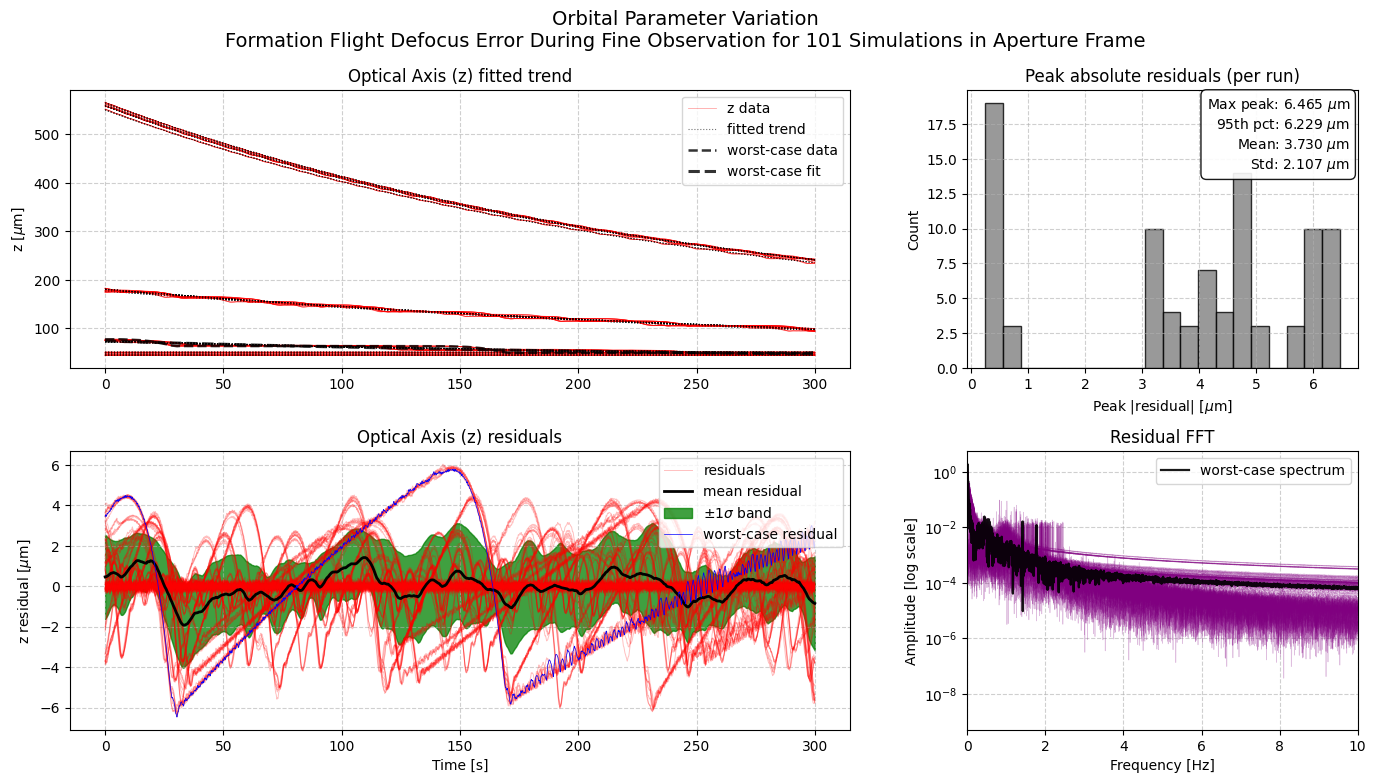

In [48]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.optimize import curve_fit

current_focal = 5000.0
alpha_lines = 0.5

def settling_model(t, y_inf, A, tau):
    return y_inf + A * np.exp(-t / tau)

rel_pos_fig = plt.figure(figsize=(14, 8))
gs = gridspec.GridSpec(
    2, 2,
    figure=rel_pos_fig,
    width_ratios=[4.0, 2],
    height_ratios=[1.0, 1.0],
    wspace=0.2,
    hspace=0.3
)

rel_pos_fig.suptitle(f"Orbital Parameter Variation\nFormation Flight Defocus Error During Fine Observation for {num_runs} Simulations in Aperture Frame", fontsize=14)

fit_ax = rel_pos_fig.add_subplot(gs[0, 0])
res_ax = rel_pos_fig.add_subplot(gs[1, 0])
hist_ax = rel_pos_fig.add_subplot(gs[0, 1])
fft_ax = rel_pos_fig.add_subplot(gs[1, 1])

fit_ax.set_title("Optical Axis (z) fitted trend")
res_ax.set_title("Optical Axis (z) residuals")
hist_ax.set_title("Peak absolute residuals (per run)")
fft_ax.set_title("Residual FFT")

fit_ax.set_ylabel("z [$\\mu$m]")
res_ax.set_ylabel("z residual [$\\mu$m]")
res_ax.set_xlabel("Time [s]")

fit_ax.grid(True, linestyle="--", alpha=0.6)
res_ax.grid(True, linestyle="--", alpha=0.6)
hist_ax.grid(True, linestyle="--", alpha=0.6)
fft_ax.grid(True, which="both", linestyle="--", alpha=0.6)

fft_ax.set_xlim([0, 10])
fft_ax.set_yscale("log")
fft_ax.set_xlabel("Frequency [Hz]")
fft_ax.set_ylabel("Amplitude [log scale]")

first_fit = True
first_raw = True
first_res = True

peak_abs_values = []
run_ids = []

# Store series so we can compute mean residual envelope and highlight the worst case
time_series = []
residual_series = []
fft_series = []

worst_case = {
    "run_idx": None,
    "peak_abs": -np.inf,
    "t": None,
    "y": None,
    "trend": None,
    "residuals": None,
    "freq": None,
    "amp": None,
}

for run_idx, (a, e, inc, raan) in enumerate(zip(a_vals, e_vals, i_vals, raan_vals)):
    t_eng = eng_times[run_idx]
    rel = rel_pos_B[run_idx]

    fine_idx = np.where(phase[run_idx] == "Fine Observation")[0]
    if len(fine_idx) == 0:
        continue

    fine_start, fine_end = full_times[run_idx][fine_idx[0]], full_times[run_idx][fine_idx[-1]]
    fine_mask = (t_eng >= fine_start) & (t_eng <= fine_end)

    fine_t = t_eng[fine_mask]
    fine_rel = rel[fine_mask]

    if len(fine_t) < 3:
        continue

    fine_t = fine_t - fine_t[0]

    fine_vals = fine_rel[:, 2].copy() - current_focal
    y_um = fine_vals * 1e6

    if len(y_um) < 3:
        continue

    y_inf0 = y_um[-1]
    A0 = y_um[0] - y_um[-1]
    tau0 = max((fine_t[-1] - fine_t[0]) / 5.0, 1e-3)

    try:
        params, _ = curve_fit(
            settling_model,
            fine_t,
            y_um,
            p0=[y_inf0, A0, tau0],
            bounds=([-np.inf, -np.inf, 1e-6], [np.inf, np.inf, np.inf]),
            maxfev=20000
        )
        trend = settling_model(fine_t, *params)
    except Exception:
        coeffs = np.polyfit(fine_t, y_um, deg=1)
        trend = np.polyval(coeffs, fine_t)

    residuals = y_um - trend

    peak_abs = np.max(np.abs(residuals))
    peak_abs_values.append(peak_abs)
    run_ids.append(run_idx)

    time_series.append(fine_t)
    residual_series.append(residuals)

    dt = np.median(np.diff(fine_t))
    freq = None
    amp = None
    if dt > 0 and len(residuals) > 3:
        resid_demean = residuals - np.mean(residuals)
        freq = np.fft.rfftfreq(len(resid_demean), d=dt)
        amp = np.abs(np.fft.rfft(resid_demean)) / len(resid_demean)
        freq = freq[1:]
        amp = amp[1:]
        fft_series.append((run_idx, freq, amp))

    # Track the worst case by peak absolute residual
    if peak_abs > worst_case["peak_abs"]:
        worst_case.update(
            {
                "run_idx": run_idx,
                "peak_abs": peak_abs,
                "t": fine_t,
                "y": y_um,
                "trend": trend,
                "residuals": residuals,
                "freq": freq,
                "amp": amp,
            }
        )

    # Base ensemble plots
    fit_ax.plot(
        fine_t, y_um,
        linewidth=0.6, color="red", alpha=0.35,
        label="z data" if first_raw else None
    )
    first_raw = False

    fit_ax.plot(
        fine_t, trend,
        linewidth=0.8, linestyle=":", color="black", alpha=0.55,
        label="fitted trend" if first_fit else None
    )
    first_fit = False

    res_ax.plot(
        fine_t, residuals,
        linewidth=0.7, color="red", alpha=0.25,
        label="residuals" if first_res else None
    )
    first_res = False

    fft_ax.plot(
        freq, amp,
        linewidth=0.5, alpha=0.25, color="purple"
    )

# Mean residual envelope and ±1σ band across runs
if len(time_series) > 0:
    max_t = max(ts[-1] for ts in time_series if len(ts) > 0)
    common_t = np.linspace(0.0, max_t, 500)

    residual_grid = np.full((len(time_series), len(common_t)), np.nan, dtype=float)
    for i, (ts, rs) in enumerate(zip(time_series, residual_series)):
        if len(ts) < 2:
            continue
        residual_grid[i, :] = np.interp(common_t, ts, rs, left=np.nan, right=np.nan)

    valid = np.sum(~np.isnan(residual_grid), axis=0) > 0
    mean_res = np.full_like(common_t, np.nan, dtype=float)
    std_res = np.full_like(common_t, np.nan, dtype=float)

    mean_res[valid] = np.nanmean(residual_grid[:, valid], axis=0)
    std_res[valid] = np.nanstd(residual_grid[:, valid], axis=0)

    res_ax.plot(
        common_t[valid], mean_res[valid],
        color="black", linewidth=2.0,
        label="mean residual"
    )
    res_ax.fill_between(
        common_t[valid],
        mean_res[valid] - std_res[valid],
        mean_res[valid] + std_res[valid],
        color="green", alpha=0.75,
        label=r"$\pm 1\sigma$ band"
    )

# Peak absolute residual histogram
if len(peak_abs_values) > 0:
    hist_ax.hist(
        peak_abs_values,
        bins=20,
        color="gray",
        edgecolor="black",
        alpha=0.8
    )
    hist_ax.set_xlabel("Peak |residual| [$\\mu$m]")
    hist_ax.set_ylabel("Count")

    max_peak = np.max(peak_abs_values)
    p95_peak = np.percentile(peak_abs_values, 95)
    mean_peak = np.mean(peak_abs_values)
    std_peak = np.std(peak_abs_values)

    textbox = (
        f"Max peak: {max_peak:.3f} $\\mu$m\n"
        f"95th pct: {p95_peak:.3f} $\\mu$m\n"
        f"Mean: {mean_peak:.3f} $\\mu$m\n"
        f"Std: {std_peak:.3f} $\\mu$m"
    )

    hist_ax.text(
        0.98, 0.98, textbox,
        transform=hist_ax.transAxes,
        va="top", ha="right",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="black", alpha=0.9)
    )

# Explicitly mark the worst-case trajectory
if worst_case["t"] is not None:
    fit_ax.plot(
        worst_case["t"], worst_case["y"],
        color="black", linewidth=1.8, linestyle='--', alpha=0.8,
        label="worst-case data"
    )
    fit_ax.plot(
        worst_case["t"], worst_case["trend"],
        color="black", linewidth=2.2, linestyle="--", alpha=0.8,
        label="worst-case fit"
    )

    res_ax.plot(
        worst_case["t"], worst_case["residuals"],
        color="blue", linewidth=0.5, linestyle="-", alpha=1,
        label="worst-case residual"
    )

    if worst_case["freq"] is not None and worst_case["amp"] is not None:
        fft_ax.plot(
            worst_case["freq"], worst_case["amp"],
            color="black", linewidth=1.6, alpha=0.9,
            label="worst-case spectrum"
        )

fit_ax.legend(loc="best")
res_ax.legend(loc="best")
fft_ax.legend(loc="best")

plt.subplots_adjust(
    left=0.06,
    right=0.98,
    top=0.88,
    bottom=0.08)
        
plt.savefig(f'./Defocus_Formation_Flight_Error.png')
# plt.show()

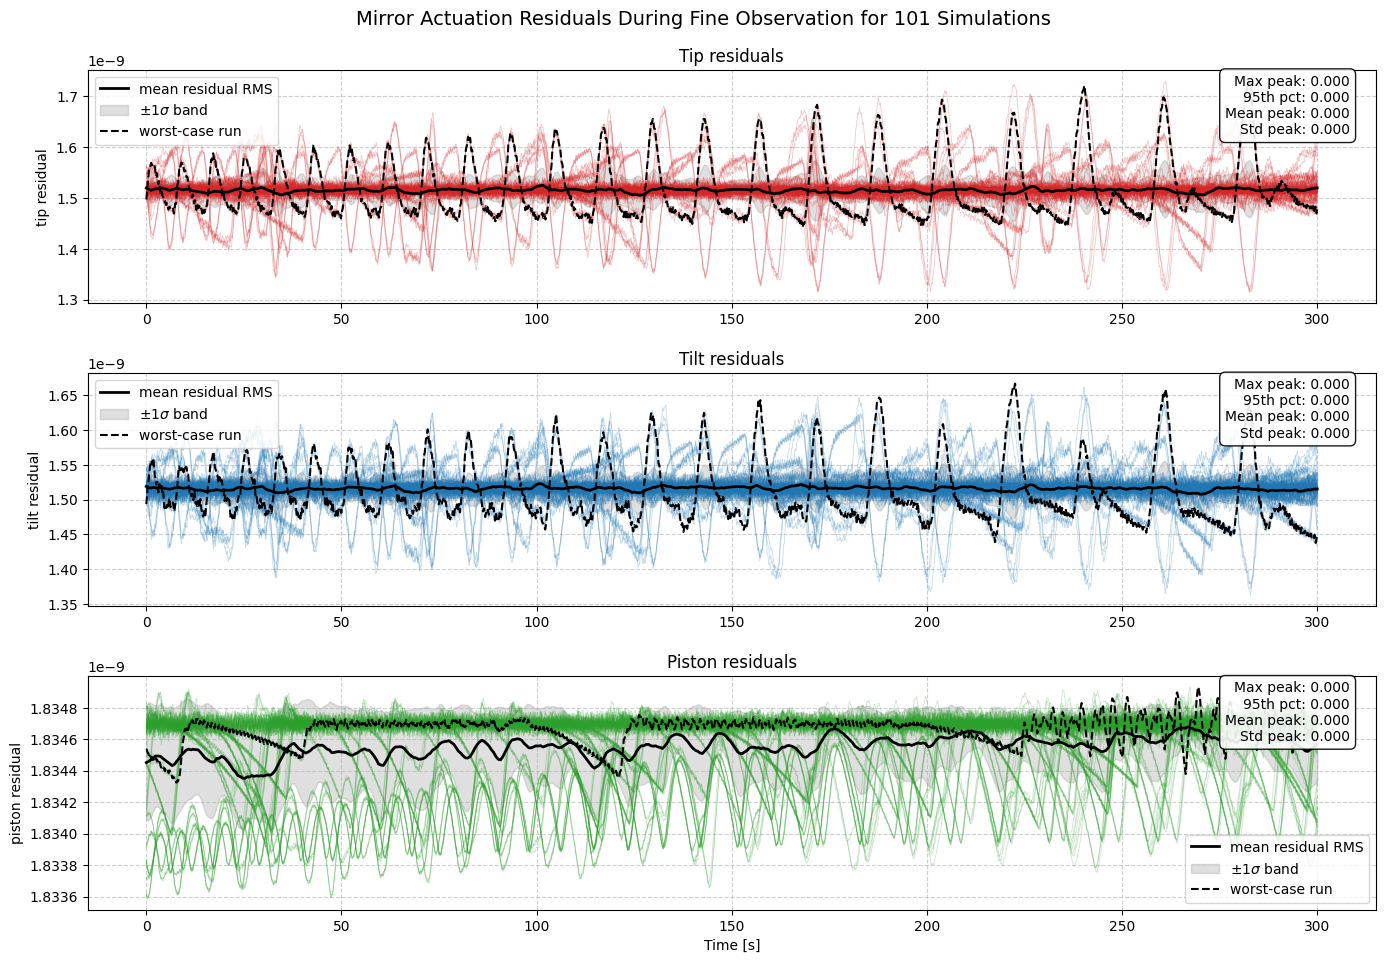

In [50]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Assumes the first 3 columns are:
# [tip, tilt, piston]
ACT_COLS = slice(0, 3)

channel_names = ["tip", "tilt", "piston"]
channel_colors = ["tab:red", "tab:blue", "tab:green"]

def _pos_only(arr):
    """
    Keep only tip/tilt/piston columns and ignore any speed columns.
    Expected shapes:
      - (N, >=3) -> returns (N, 3)
      - (>=3,)   -> returns (3,)
    """
    arr = np.asarray(arr)
    if arr.ndim == 1:
        if arr.shape[0] < 3:
            raise ValueError(f"Expected at least 3 elements, got shape {arr.shape}")
        return arr[:3]
    if arr.ndim == 2:
        if arr.shape[1] < 3:
            raise ValueError(f"Expected at least 3 columns, got shape {arr.shape}")
        return arr[:, ACT_COLS]
    raise ValueError(f"Unsupported array shape: {arr.shape}")

mirror_fig = plt.figure(figsize=(14, 10))
gs = gridspec.GridSpec(
    3, 1,
    figure=mirror_fig,
    hspace=0.30
)

mirror_fig.suptitle(
    f"Mirror Actuation Residuals During Fine Observation for {num_runs} Simulations",
    fontsize=14
)

axes = [mirror_fig.add_subplot(gs[i, 0]) for i in range(3)]

for ch, ax in enumerate(axes):
    ax.set_title(f"{channel_names[ch].capitalize()} residuals")
    ax.set_ylabel(f"{channel_names[ch]} residual")
    ax.grid(True, linestyle="--", alpha=0.6)

axes[-1].set_xlabel("Time [s]")

# Store per-channel time series so we can compute a mean envelope later
time_series = {0: [], 1: [], 2: []}
residual_series = {0: [], 1: [], 2: []}
peak_abs_values = {0: [], 1: [], 2: []}
worst_case = {
    0: {"peak_abs": -np.inf, "t": None, "resid": None},
    1: {"peak_abs": -np.inf, "t": None, "resid": None},
    2: {"peak_abs": -np.inf, "t": None, "resid": None},
}

for run_idx, (a, e, inc, raan) in enumerate(zip(a_vals, e_vals, i_vals, raan_vals)):
    t_eng = np.asarray(eng_times[run_idx])

    fine_idx = np.where(phase[run_idx] == "Fine Observation")[0]
    if len(fine_idx) == 0:
        continue

    fine_start, fine_end = full_times[run_idx][fine_idx[0]], full_times[run_idx][fine_idx[-1]]
    fine_mask = (t_eng >= fine_start) & (t_eng <= fine_end)

    fine_t = t_eng[fine_mask]
    if len(fine_t) < 3:
        continue

    fine_t = fine_t - fine_t[0]

    ma_segments = mirror_actuation[run_idx]
    dma_segments = desired_mirror_actuation[run_idx]

    if len(ma_segments) != len(dma_segments):
        raise ValueError(
            f"Run {run_idx}: mirror_actuation has {len(ma_segments)} segments, "
            f"desired_mirror_actuation has {len(dma_segments)} segments"
        )

    # Collect residuals for all segments: shape -> (N_time, N_seg, 3)
    seg_residuals = []
    valid_segment_count = 0

    for s in range(len(ma_segments)):
        act_seg = np.asarray(ma_segments[s])
        des_seg = np.asarray(dma_segments[s])

        if act_seg.shape != des_seg.shape:
            raise ValueError(
                f"Run {run_idx}, segment {s}: shape mismatch "
                f"{act_seg.shape} vs {des_seg.shape}"
            )

        if act_seg.ndim != 2 or act_seg.shape[0] != len(t_eng):
            raise ValueError(
                f"Run {run_idx}, segment {s}: expected shape (len(time), >=3 or >=6), got {act_seg.shape}"
            )

        # Keep only tip/tilt/piston, ignore speeds
        act_pos = _pos_only(act_seg[fine_mask])
        des_pos = _pos_only(des_seg[fine_mask])

        resid = act_pos - des_pos  # actual minus desired
        seg_residuals.append(resid)
        valid_segment_count += 1

    if valid_segment_count == 0:
        continue

    # Shape: (N_time, N_seg, 3)
    seg_residuals = np.stack(seg_residuals, axis=1)

    for ch in range(3):
        # RMS across the 7 segments, per time sample
        channel_rms_t = np.sqrt(np.mean(seg_residuals[:, :, ch] ** 2, axis=1))

        peak_abs = np.max(np.abs(seg_residuals[:, :, ch]))
        peak_abs_values[ch].append(peak_abs)

        time_series[ch].append(fine_t)
        residual_series[ch].append(channel_rms_t)

        axes[ch].plot(
            fine_t,
            channel_rms_t,
            color=channel_colors[ch],
            linewidth=0.6,
            alpha=0.25
        )

        if peak_abs > worst_case[ch]["peak_abs"]:
            worst_case[ch]["peak_abs"] = peak_abs
            worst_case[ch]["t"] = fine_t
            worst_case[ch]["resid"] = channel_rms_t

# Mean residual envelope and ±1σ band
for ch, ax in enumerate(axes):
    if len(time_series[ch]) == 0:
        continue

    max_t = max(ts[-1] for ts in time_series[ch] if len(ts) > 0)
    common_t = np.linspace(0.0, max_t, 500)

    residual_grid = np.full((len(time_series[ch]), len(common_t)), np.nan, dtype=float)
    for i, (ts, rs) in enumerate(zip(time_series[ch], residual_series[ch])):
        if len(ts) < 2:
            continue
        residual_grid[i, :] = np.interp(common_t, ts, rs, left=np.nan, right=np.nan)

    valid = np.sum(~np.isnan(residual_grid), axis=0) > 0
    mean_res = np.full_like(common_t, np.nan, dtype=float)
    std_res = np.full_like(common_t, np.nan, dtype=float)

    mean_res[valid] = np.nanmean(residual_grid[:, valid], axis=0)
    std_res[valid] = np.nanstd(residual_grid[:, valid], axis=0)

    ax.plot(
        common_t[valid], mean_res[valid],
        color="black", linewidth=2.0,
        label="mean residual RMS"
    )
    ax.fill_between(
        common_t[valid],
        mean_res[valid] - std_res[valid],
        mean_res[valid] + std_res[valid],
        color="gray", alpha=0.25,
        label=r"$\pm 1\sigma$ band"
    )

    if worst_case[ch]["t"] is not None:
        ax.plot(
            worst_case[ch]["t"],
            worst_case[ch]["resid"],
            color="black",
            linewidth=1.5,
            linestyle="--",
            label="worst-case run"
        )

    max_peak = np.max(peak_abs_values[ch])
    p95_peak = np.percentile(peak_abs_values[ch], 95)
    mean_peak = np.mean(peak_abs_values[ch])
    std_peak = np.std(peak_abs_values[ch])

    textbox = (
        f"Max peak: {max_peak:.3f}\n"
        f"95th pct: {p95_peak:.3f}\n"
        f"Mean peak: {mean_peak:.3f}\n"
        f"Std peak: {std_peak:.3f}"
    )

    ax.text(
        0.98, 0.98, textbox,
        transform=ax.transAxes,
        va="top", ha="right",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="black", alpha=0.9)
    )

    ax.legend(loc="best")

plt.subplots_adjust(
    left=0.06,
    right=0.98,
    top=0.92,
    bottom=0.08
)

plt.savefig("./Mirror_Actuation_Residuals.png", bbox_inches="tight", pad_inches=0.02)
# plt.show()

Plotting Point on Detector Plane: 100%|██████████| 101/101 [00:11<00:00,  9.11it/s]


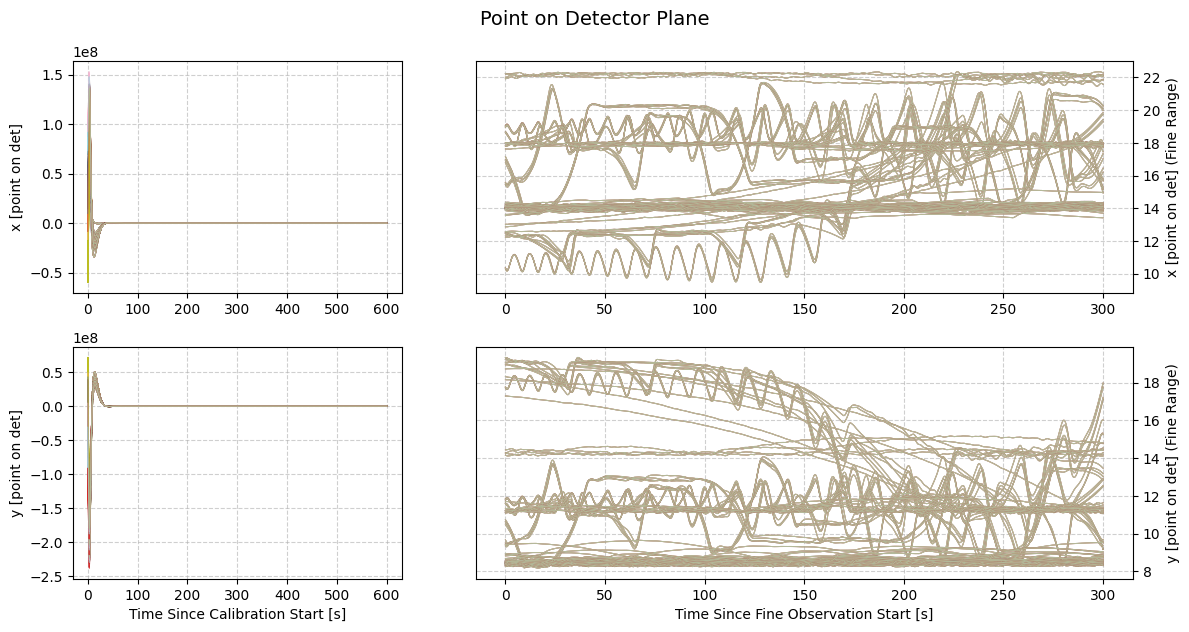

Plotting Mirror Actuation: 100%|██████████| 101/101 [00:28<00:00,  3.60it/s]


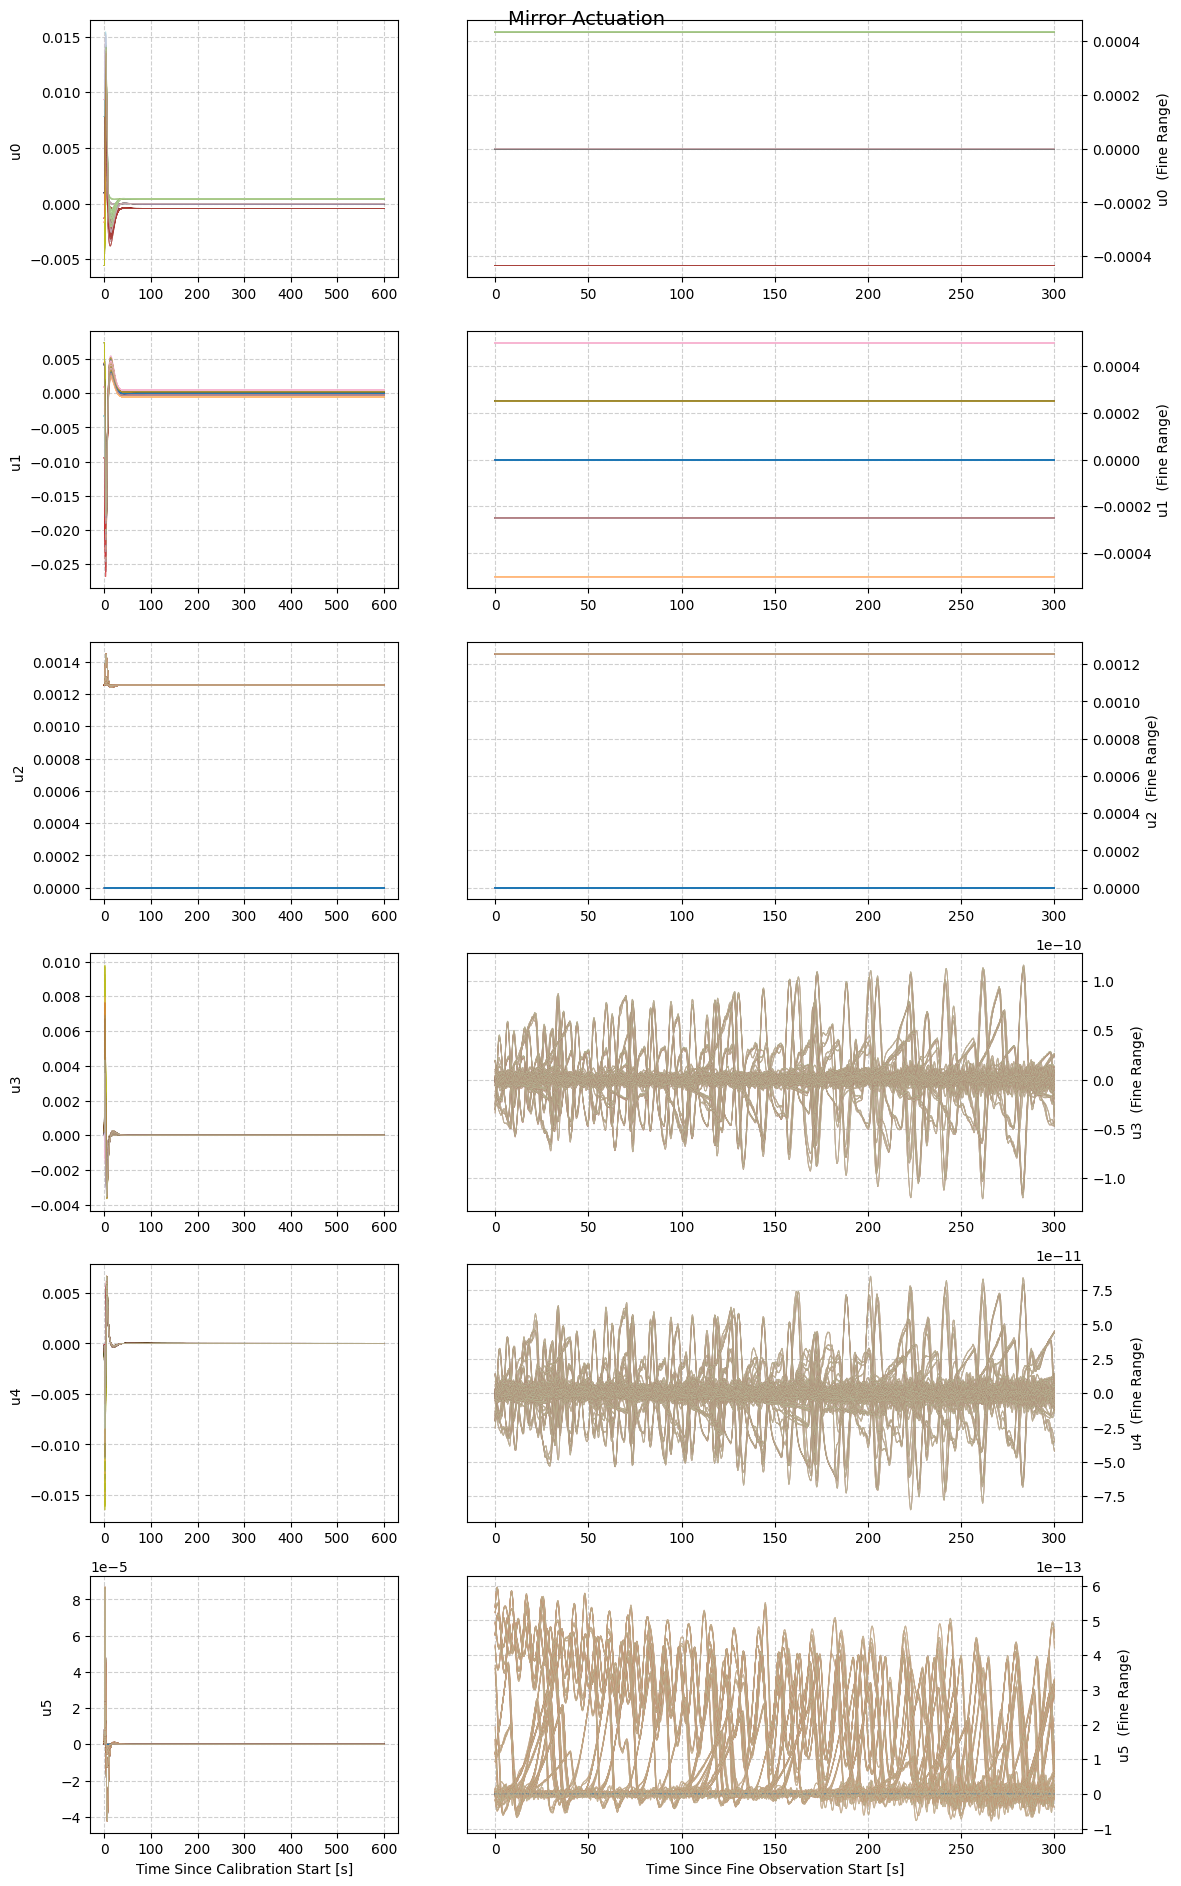

Plotting Desired Mirror Actuation: 100%|██████████| 101/101 [00:28<00:00,  3.53it/s]


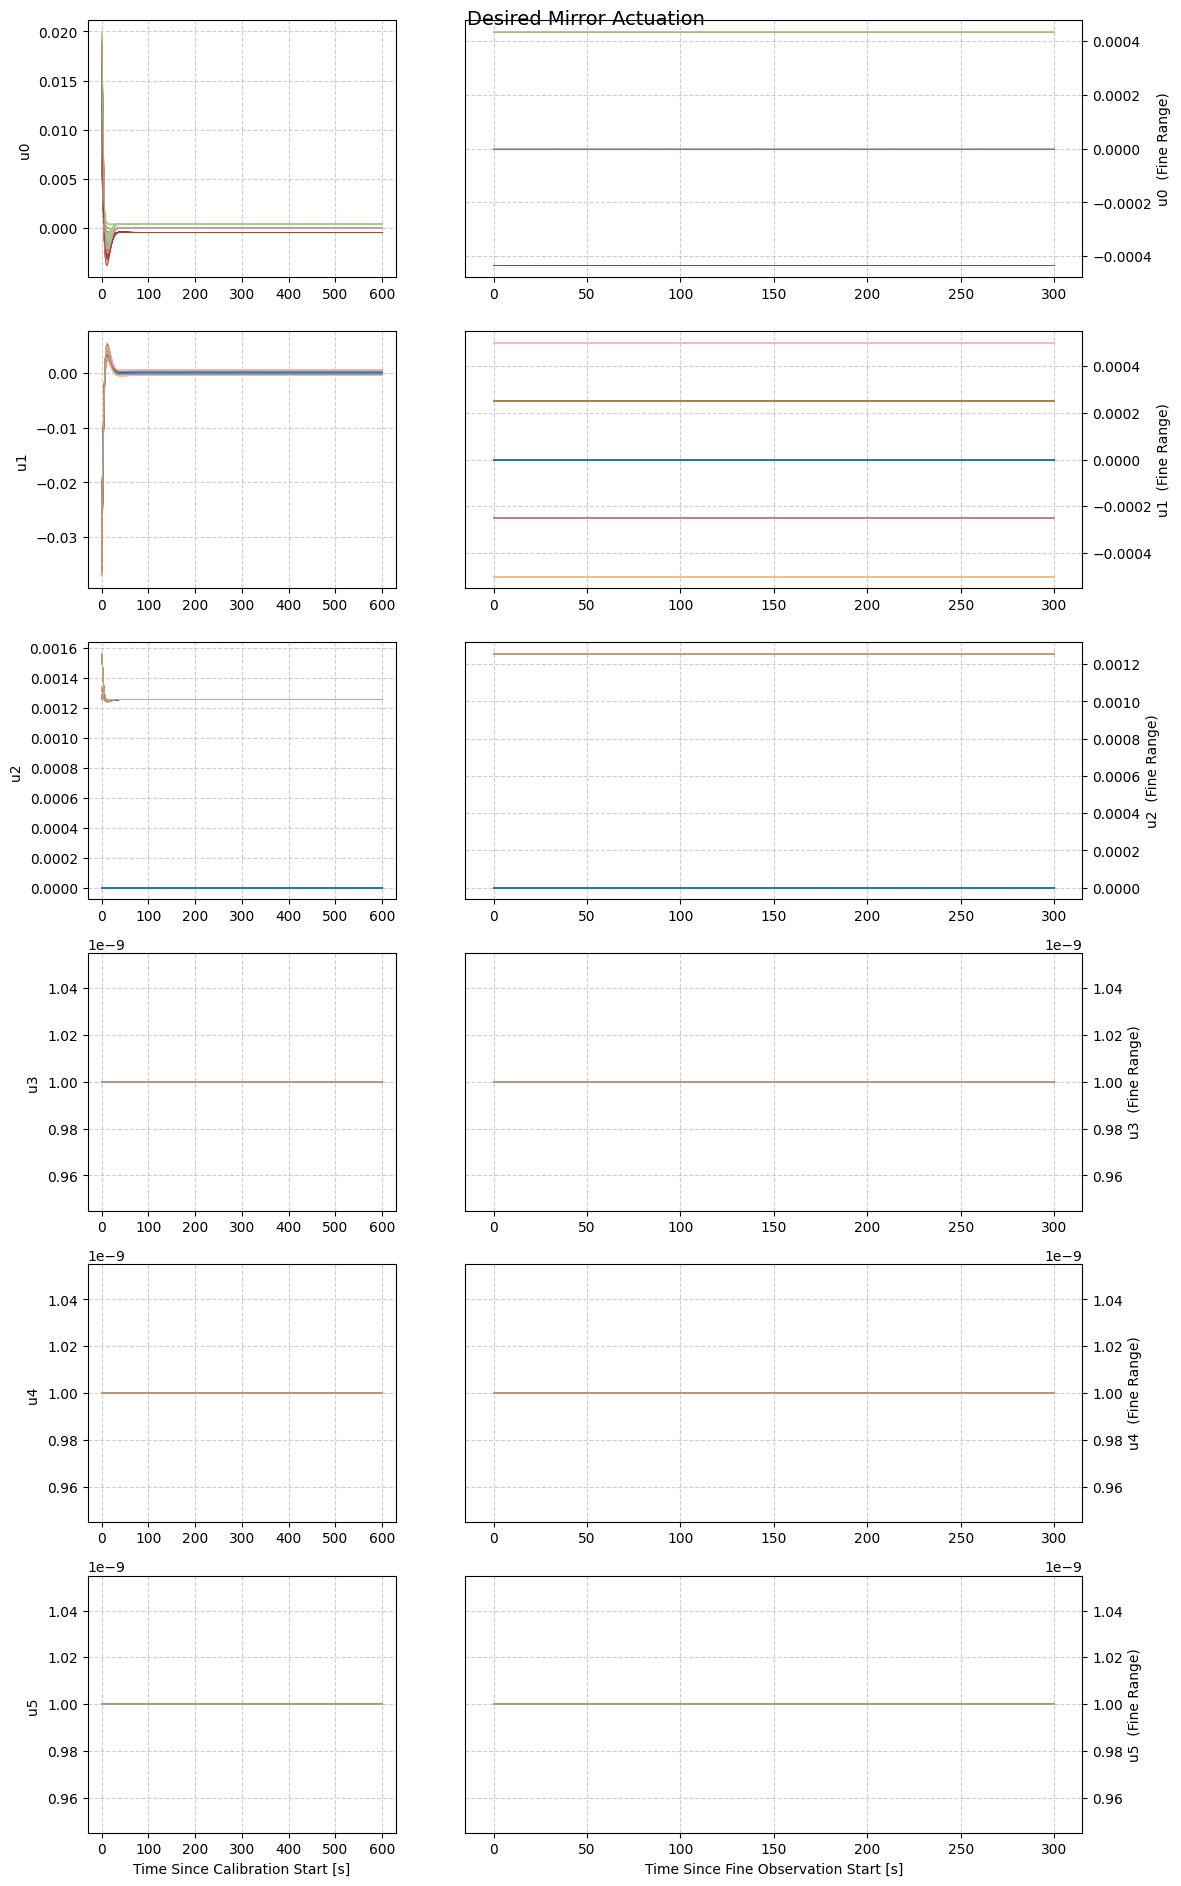

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from tqdm import tqdm

def plot_quantity_all_segments(
    quantity_list,
    title,
    component_labels=None,
    y_scale=1.0,
    y_suffix="",
    cmap_name="tab20",
    segment_alpha=0.35,
    line_width=0.6,
):
    """
    Plot every segment for every run, without averaging across segments.

    quantity_list:
        Outer list over runs.
        Inner list over segments.
        Each segment is an array of shape (T, N).
    """

    if len(quantity_list) == 0 or len(quantity_list[0]) == 0:
        raise ValueError(f"{title}: empty quantity_list")

    num_components = np.asarray(quantity_list[0][0]).shape[1]
    if component_labels is None:
        component_labels = [f"c{i}" for i in range(num_components)]

    max_segments = max(len(run) for run in quantity_list)
    cmap = plt.get_cmap(cmap_name, max(max_segments, 1))

    fig = plt.figure(figsize=(12, 3.2 * num_components))
    gs = gridspec.GridSpec(num_components, 2, width_ratios=[1, 2], figure=fig)
    fig.suptitle(title, fontsize=14)

    ax_pairs = []
    for row in range(num_components):
        ax_cal = fig.add_subplot(gs[row, 0])
        ax_fine = fig.add_subplot(gs[row, 1])

        ax_fine.yaxis.tick_right()
        ax_fine.yaxis.set_label_position("right")

        ax_pairs.append((ax_cal, ax_fine))

    ax_pairs[-1][0].set_xlabel("Time Since Calibration Start [s]")
    ax_pairs[-1][1].set_xlabel("Time Since Fine Observation Start [s]")

    for coord in range(num_components):
        ax_pairs[coord][0].set_ylabel(f"{component_labels[coord]} {y_suffix}")
        ax_pairs[coord][1].set_ylabel(f"{component_labels[coord]} {y_suffix} (Fine Range)")
        ax_pairs[coord][0].grid(True, linestyle="--", alpha=0.6)
        ax_pairs[coord][1].grid(True, linestyle="--", alpha=0.6)

    for i in tqdm(range(num_runs), desc=f"Plotting {title}"):
        t_eng = eng_times[i]

        cal_idx = np.where(phase[i] == "Calibration")[0]
        fine_idx = np.where(phase[i] == "Fine Observation")[0]

        if len(cal_idx) > 0:
            cal_start, cal_end = full_times[i][cal_idx[0]], full_times[i][cal_idx[-1]]
            cal_mask = (t_eng >= cal_start) & (t_eng <= cal_end)
        else:
            cal_mask = np.zeros_like(t_eng, dtype=bool)

        if len(fine_idx) > 0:
            fine_start, fine_end = full_times[i][fine_idx[0]], full_times[i][fine_idx[-1]]
            fine_mask = (t_eng >= fine_start) & (t_eng <= fine_end)
        else:
            fine_mask = np.zeros_like(t_eng, dtype=bool)

        cal_t = t_eng[cal_mask]
        fine_t = t_eng[fine_mask]

        if len(cal_t) > 0:
            cal_t = cal_t - cal_t[0]
        if len(fine_t) > 0:
            fine_t = fine_t - fine_t[0]

        # Plot each segment separately
        for s, seg_data in enumerate(quantity_list[i]):
            seg_data = np.asarray(seg_data)

            if seg_data.ndim != 2 or seg_data.shape[1] != num_components:
                raise ValueError(
                    f"{title}: run {i}, segment {s} has shape {seg_data.shape}, "
                    f"expected (T, {num_components})"
                )

            seg_color = cmap(s % cmap.N)

            cal_vals_all = seg_data[cal_mask]
            fine_vals_all = seg_data[fine_mask]

            for coord in range(num_components):
                cal_vals = cal_vals_all[:, coord] if len(cal_vals_all) > 0 else np.array([])
                fine_vals = fine_vals_all[:, coord] if len(fine_vals_all) > 0 else np.array([])

                if len(cal_t) > 0 and len(cal_vals) > 0:
                    ax_pairs[coord][0].plot(
                        cal_t,
                        cal_vals * y_scale,
                        linewidth=line_width,
                        color=seg_color,
                        alpha=segment_alpha,
                    )

                if len(fine_t) > 0 and len(fine_vals) > 0:
                    ax_pairs[coord][1].plot(
                        fine_t,
                        fine_vals * y_scale,
                        linewidth=line_width,
                        color=seg_color,
                        alpha=segment_alpha,
                    )

    plt.tight_layout()
    plt.subplots_adjust(wspace=0.15)
    plt.show()


# Point on detector plane: x and y
plot_quantity_all_segments(
    point_on_det_plane,
    title="Point on Detector Plane",
    component_labels=["x", "y"],
    y_scale=1e6,
    y_suffix="[point on det]",
    cmap_name="tab20",
    segment_alpha=0.45,
    line_width=0.7,
)

# Mirror actuation: 6 components
plot_quantity_all_segments(
    mirror_actuation,
    title="Mirror Actuation",
    component_labels=[f"u{i}" for i in range(6)],
    y_scale=1.0,
    y_suffix="",
    cmap_name="tab20",
    segment_alpha=0.35,
    line_width=0.6,
)

# Desired mirror actuation: 6 components
plot_quantity_all_segments(
    desired_mirror_actuation,
    title="Desired Mirror Actuation",
    component_labels=[f"u{i}" for i in range(6)],
    y_scale=1.0,
    y_suffix="",
    cmap_name="tab20",
    segment_alpha=0.35,
    line_width=0.6,
)

Building detector heatmaps: 100%|██████████| 101/101 [00:08<00:00, 12.40it/s]


Heatmaps built.


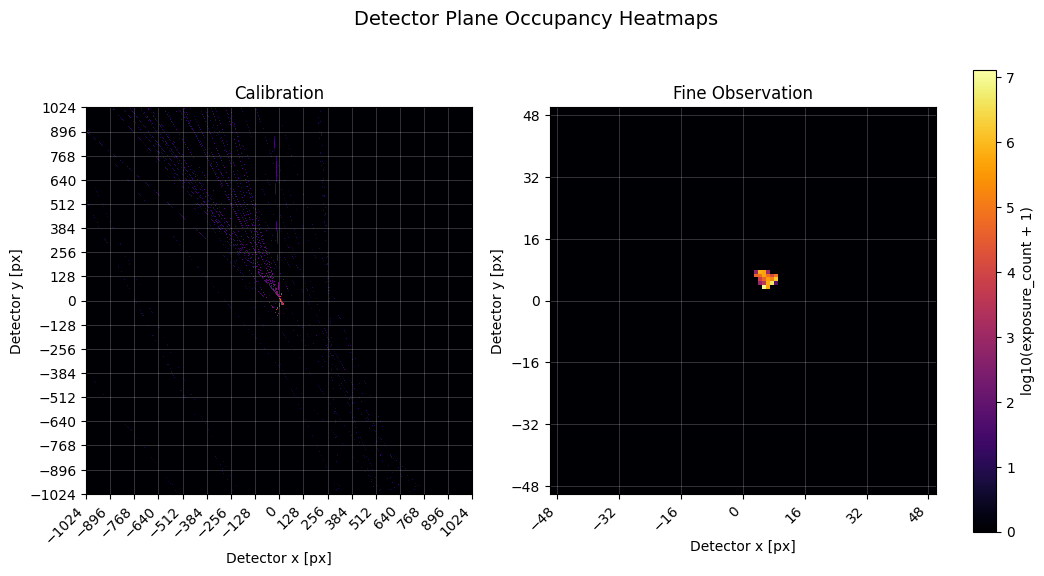

In [34]:
det_num_pixels = 2048
det_pixel_size = 2.5e-6  # meters
det_size_m = det_num_pixels * det_pixel_size
half_size_m = det_size_m / 2.0

# Plot in pixel coordinates so the detector is visibly a 2048 x 2048 grid.
# Pixel centers run from -1023.5 to +1023.5, with edges at -1024 to +1024.
x_edges = np.arange(det_num_pixels + 1) - det_num_pixels / 2
y_edges = np.arange(det_num_pixels + 1) - det_num_pixels / 2


def _accumulate_centered_heatmap(heatmap, xy_m):
    """
    Accumulate (x, y) points in meters into a centered detector heatmap.

    Detector spans:
        x in [-half_size_m, +half_size_m)
        y in [-half_size_m, +half_size_m)
    """
    if xy_m.size == 0:
        return

    xy_m = np.asarray(xy_m)
    if xy_m.ndim != 2 or xy_m.shape[1] != 2:
        raise ValueError(f"Expected shape (N, 2), got {xy_m.shape}")

    x = xy_m[:, 0]
    y = xy_m[:, 1]

    x_idx = np.floor((x + half_size_m) / det_pixel_size).astype(int)
    y_idx = np.floor((y + half_size_m) / det_pixel_size).astype(int)

    valid = (
        (x_idx >= 0) & (x_idx < det_num_pixels) &
        (y_idx >= 0) & (y_idx < det_num_pixels)
    )

    np.add.at(heatmap, (y_idx[valid], x_idx[valid]), 1)


# ---------------------------------------------------------------------
# Build calibration / fine-observation detector heatmaps
# ---------------------------------------------------------------------
cal_heat = np.zeros((det_num_pixels, det_num_pixels), dtype=np.float64)
fine_heat = np.zeros((det_num_pixels, det_num_pixels), dtype=np.float64)

for i in tqdm(range(num_runs), desc="Building detector heatmaps"):
    t_eng = eng_times[i]

    cal_idx = np.where(phase[i] == "Calibration")[0]
    fine_idx = np.where(phase[i] == "Fine Observation")[0]

    if len(cal_idx) > 0:
        cal_start, cal_end = full_times[i][cal_idx[0]], full_times[i][cal_idx[-1]]
        cal_mask = (t_eng >= cal_start) & (t_eng <= cal_end)
    else:
        cal_mask = np.zeros_like(t_eng, dtype=bool)

    if len(fine_idx) > 0:
        fine_start, fine_end = full_times[i][fine_idx[0]], full_times[i][fine_idx[-1]]
        fine_mask = (t_eng >= fine_start) & (t_eng <= fine_end)
    else:
        fine_mask = np.zeros_like(t_eng, dtype=bool)

    for seg_data in point_on_det_plane[i]:
        seg_data = np.asarray(seg_data)

        if seg_data.ndim != 2 or seg_data.shape[1] != 2:
            raise ValueError(
                f"point_on_det_plane run {i} has bad segment shape {seg_data.shape}; expected (T, 2)"
            )

        cal_xy = seg_data[cal_mask]
        fine_xy = seg_data[fine_mask]

        _accumulate_centered_heatmap(cal_heat, cal_xy)
        _accumulate_centered_heatmap(fine_heat, fine_xy)

print("Heatmaps built.")


# ---------------------------------------------------------------------
# Plot gridded detector heatmaps in pixel coordinates
# ---------------------------------------------------------------------
fig = plt.figure(figsize=(12, 6))
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1], figure=fig)
fig.suptitle("Detector Plane Occupancy Heatmaps", fontsize=14)

ax_cal = fig.add_subplot(gs[0, 0])
ax_fine = fig.add_subplot(gs[0, 1])

cal_plot = np.log10(cal_heat + 1)
fine_plot = np.log10(fine_heat + 1)
vmax = max(cal_plot.max(), fine_plot.max())

im0 = ax_cal.pcolormesh(
    x_edges,
    y_edges,
    cal_plot,
    cmap="inferno",
    vmin=0,
    vmax=vmax,
    shading="flat",
)
ax_cal.set_title("Calibration")
ax_cal.set_xlabel("Detector x [px]")
ax_cal.set_ylabel("Detector y [px]")
ax_cal.set_aspect("equal")
ax_cal.set_xlim(-det_num_pixels / 2, det_num_pixels / 2)
ax_cal.set_ylim(-det_num_pixels / 2, det_num_pixels / 2)

im1 = ax_fine.pcolormesh(
    x_edges,
    y_edges,
    fine_plot,
    cmap="inferno",
    vmin=0,
    vmax=vmax,
    shading="flat",
)
ax_fine.set_title("Fine Observation")
ax_fine.set_xlabel("Detector x [px]")
ax_fine.set_ylabel("Detector y [px]")
ax_fine.set_aspect("equal")

# Zoom the fine detector view in pixel units
zoom = 50  # pixels
ax_fine.set_xlim(-zoom, zoom)
ax_fine.set_ylim(-zoom, zoom)

# Grid lines every N pixels
grid_step_cal = 128
grid_step_fine = 16

ax_cal.xaxis.set_major_locator(MultipleLocator(grid_step_cal))
ax_cal.yaxis.set_major_locator(MultipleLocator(grid_step_cal))
ax_cal.grid(color="white", linewidth=0.4, alpha=0.35)

ax_fine.xaxis.set_major_locator(MultipleLocator(grid_step_fine))
ax_fine.yaxis.set_major_locator(MultipleLocator(grid_step_fine))
ax_fine.grid(color="white", linewidth=0.4, alpha=0.35)

for ax in (ax_cal, ax_fine):
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_ha('right')

cbar = fig.colorbar(im1, ax=[ax_cal, ax_fine], fraction=0.046, pad=0.04)
cbar.set_label("log10(exposure_count + 1)")

plt.savefig(f'./{path}/heatmap_logged.png', dpi=300, bbox_inches="tight")